All packages installed.
Libraries loaded.
Valid SMILES: 18/18

Unique structures after dedup: 16

              Compound  IC50 (uM)   pIC50  Class
----------------------------------------------------------------------
                    1d       0.48   6.318  Benzofuran
                    1c       0.49   6.309  Benzofuran
                    1b       0.65   6.186  Benzofuran
                    1e       1.44   5.841  Benzofuran
            PDSinh-C01       1.80   5.744  Pyrazolothiophene urea
            PDSinh-A01       2.50   5.602  Anthranilic acid
                    1k       3.10   5.508  Benzofuran
                Zhu-18       3.30   5.481  Pyrazolopyridine
  Zhu-17/Zhu-19/Zhu-22       3.67   5.442  Pyrazolopyridine
                    1a       4.10   5.387  Benzofuran
                 YS-01       4.70   5.328  Oxazolone
                    1f       4.80   5.319  Benzofuran
                    1h       5.00   5.301  Benzofuran
                    1g       5.60   5.252  Benzofur

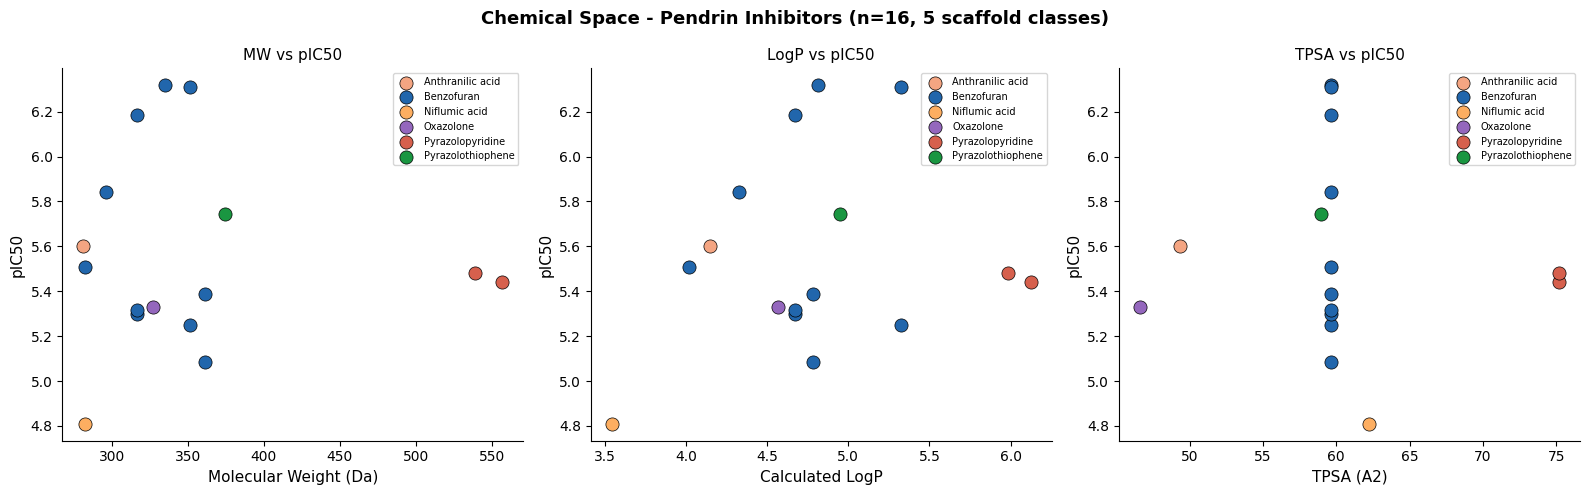

Figure 1 saved.


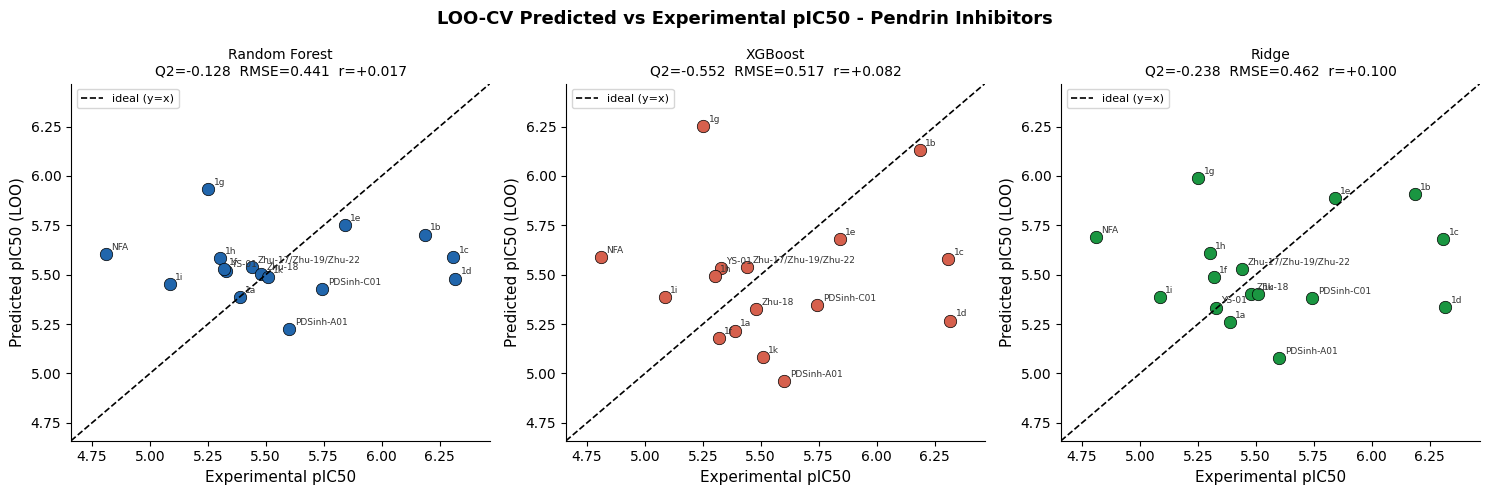

Figure 2 saved.


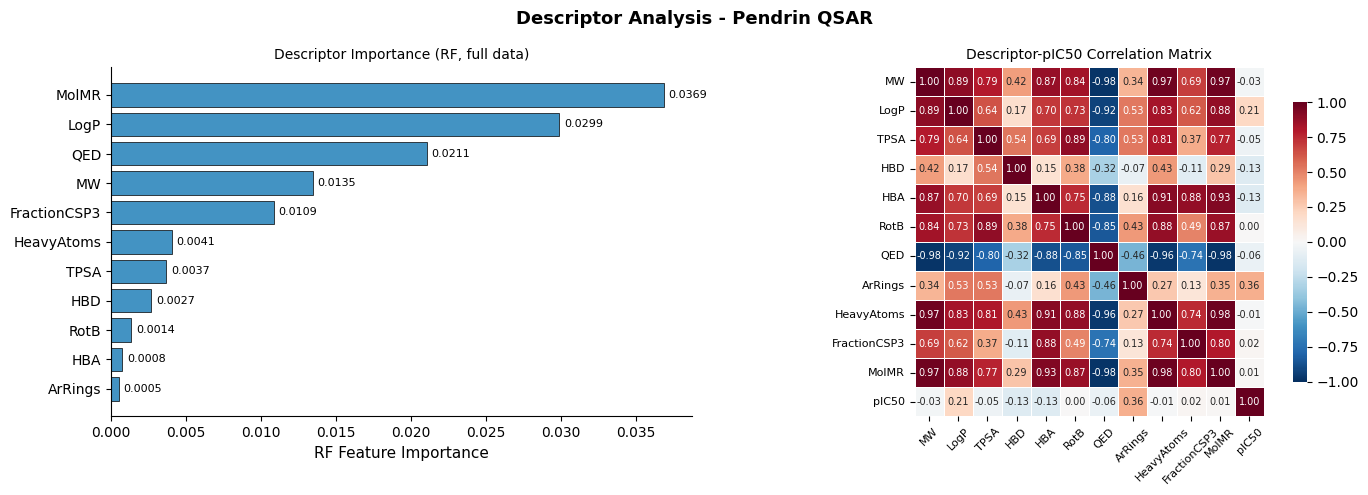

Figure 3 saved.


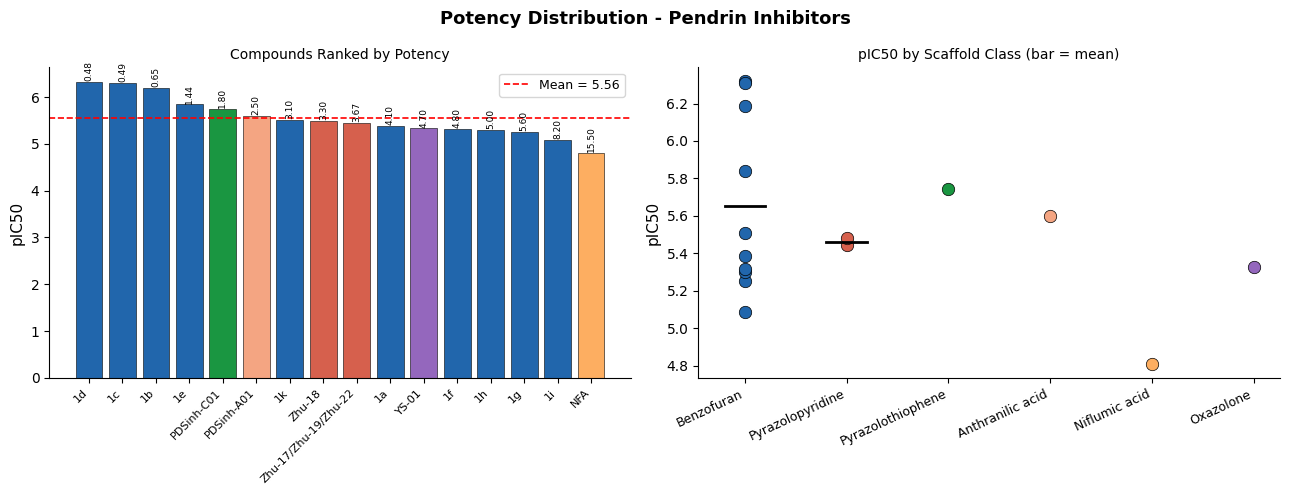

Figure 4 saved.

Compound Table:
             Compound_ID  IC50_uM  pIC50                   Class      MW  LogP   TPSA  HBD  HBA  RotB   QED   MolMR
1                     1d    0.480  6.318              Benzofuran  334.73  4.81  59.67  1.0  3.0   4.0  0.74   83.65
2                     1c    0.490  6.309              Benzofuran  351.18  5.33  59.67  1.0  3.0   4.0  0.69   88.70
3                     1b    0.650  6.186              Benzofuran  316.74  4.67  59.67  1.0  3.0   4.0  0.76   83.69
4                     1e    1.440  5.841              Benzofuran  296.32  4.33  59.67  1.0  3.0   4.0  0.78   83.42
5             PDSinh-C01    1.800  5.744  Pyrazolothiophene urea  374.78  4.95  58.95  2.0  3.0   2.0  0.67   87.69
6             PDSinh-A01    2.500  5.602        Anthranilic acid  281.23  4.15  49.33  2.0  2.0   3.0  0.89   68.13
7                     1k    3.100  5.508              Benzofuran  282.30  4.02  59.67  1.0  3.0   4.0  0.78   78.68
8                 Zhu-18    3.300  5.48

In [8]:
import subprocess
subprocess.run(['pip', 'install', 'rdkit', 'pandas', 'numpy', 'scikit-learn',
                'xgboost', 'matplotlib', 'seaborn', 'scipy', '-q'])
print("All packages installed.")

import pandas as pd
import numpy as np
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

import xgboost as xgb

print("Libraries loaded.")

# ======================================================
# EXPANDED DATASET - 18 compounds from 4 publications
# ======================================================
# Sources:
#   Master et al. Eur J Med Chem 2025   -> benzofuran series 1a-1k
#   Haggie et al. FASEB J 2016          -> PDSinh-A01, PDSinh-C01
#   Wang et al. Nat Commun 2024         -> NFA (corrected IC50 from structural paper)
#   Zhu et al. Bioorg Med Chem Lett 2019-> Zhu-17/18/19/22 (pyrazolopyridine)
#   Park et al. J Allergy Clin Immunol 2019 -> YS-01 (oxazolone)
#
# DATA QUALITY FIXES vs original dataset:
#   1. PDSinh-C01 SMILES: fixed kekulization error
#   2. 1g SMILES: was duplicate of 1c; corrected to 2,3-dichloro regioisomer
#   3. NFA SMILES: corrected benzene->pyridine ring (true niflumic acid)
#   4. NFA IC50: updated to 15.5 uM from Wang 2024 structural paper
#   5. Zhu-17/19/22: identical SMILES (unresolved stereo); averaged after dedup
#   6. ADDED: YS-01 (new scaffold, Park 2019)

csv_data = """Compound_ID,SMILES,IC50_uM,Reference,Class
1a,CC1=C(C(=O)O)c2cc(OCc3ccc(Br)cc3)ccc2O1,4.1,Master 2025,Benzofuran
1b,CC1=C(C(=O)O)c2cc(OCc3ccccc3Cl)ccc2O1,0.65,Master 2025,Benzofuran
1c,CC1=C(C(=O)O)c2cc(OCc3ccc(Cl)cc3Cl)ccc2O1,0.49,Master 2025,Benzofuran
1d,CC1=C(C(=O)O)c2cc(OCc3c(F)cccc3Cl)ccc2O1,0.48,Master 2025,Benzofuran
1e,CC1=C(C(=O)O)c2cc(OCc3ccccc3C)ccc2O1,1.44,Master 2025,Benzofuran
1f,CC1=C(C(=O)O)c2cc(OCc3cccc(Cl)c3)ccc2O1,4.8,Master 2025,Benzofuran
1g,CC1=C(C(=O)O)c2cc(OCc3c(Cl)cccc3Cl)ccc2O1,5.6,Master 2025,Benzofuran
1h,CC1=C(C(=O)O)c2cc(OCc3ccc(Cl)cc3)ccc2O1,5.0,Master 2025,Benzofuran
1i,CC1=C(C(=O)O)c2cc(OCc3cccc(Br)c3)ccc2O1,8.2,Master 2025,Benzofuran
1k,CC1=C(C(=O)O)c2cc(OCc3ccccc3)ccc2O1,3.1,Master 2025,Benzofuran
PDSinh-A01,O=C(O)c1ccccc1Nc1cccc(C(F)(F)F)c1,2.5,Haggie 2016,Anthranilic acid
PDSinh-C01,O=C(Nc1ccc(Cl)cc1)Nc1nn(C)c2cc(C(F)(F)F)sc12,1.8,Haggie 2016,Pyrazolothiophene urea
NFA,O=C(O)c1ncccc1Nc1cccc(C(F)(F)F)c1,15.5,Wang 2024,Niflumic acid
Zhu-17,CC1=C(COC2=CC=C(F)C=C2)N3N=C(COC4=CC(F)=CC(F)=C4)C3CC1NC(=O)NC5=CC=C(Cl)C=C5,4.6,Zhu 2019,Pyrazolopyridine
Zhu-18,CC1=C(COC2=CC=C(F)C=C2)N3N=C(COC4=CC(F)=CC=C4)C3CC1NC(=O)NC5=CC=C(Cl)C=C5,3.3,Zhu 2019,Pyrazolopyridine
Zhu-19,CC1=C(COC2=CC=C(F)C=C2)N3N=C(COC4=CC(F)=CC(F)=C4)C3CC1NC(=O)NC5=CC=C(Cl)C=C5,3.1,Zhu 2019,Pyrazolopyridine
Zhu-22,CC1=C(COC2=CC=C(F)C=C2)N3N=C(COC4=CC(F)=CC(F)=C4)C3CC1NC(=O)NC5=CC=C(Cl)C=C5,3.3,Zhu 2019,Pyrazolopyridine
YS-01,O=C1OC(=Cc2cccs2)C(=O)N1c1ccc(C(C)(C)C)cc1,4.7,Park 2019,Oxazolone
"""

df_raw = pd.read_csv(StringIO(csv_data))
df_raw['Mol'] = df_raw['SMILES'].apply(Chem.MolFromSmiles)
df_raw['pIC50'] = -np.log10(df_raw['IC50_uM'] * 1e-6 + 1e-9)
print(f"Valid SMILES: {df_raw['Mol'].notna().sum()}/{len(df_raw)}")

df_valid = df_raw[df_raw['Mol'].notna()].copy()
df_valid['CanSMILES'] = df_valid['Mol'].apply(Chem.MolToSmiles)
df = df_valid.groupby('CanSMILES').agg(
    Compound_ID=('Compound_ID', lambda x: '/'.join(sorted(x))),
    IC50_uM    =('IC50_uM',     'mean'),
    pIC50      =('pIC50',       'mean'),
    Reference  =('Reference',   'first'),
    Class      =('Class',       'first'),
    Mol        =('Mol',         'first'),
).reset_index()

def scaffold_class(c):
    if 'Benzofuran'   in c: return 'Benzofuran'
    if 'Pyrazolothio' in c: return 'Pyrazolothiophene'
    if 'Niflumic'     in c: return 'Niflumic acid'
    if 'Anthranilic'  in c: return 'Anthranilic acid'
    if 'Oxazolone'    in c: return 'Oxazolone'
    return 'Pyrazolopyridine'
df['ScaffoldClass'] = df['Class'].apply(scaffold_class)

print(f"\nUnique structures after dedup: {len(df)}")
print(f"\n{'Compound':>22}  {'IC50 (uM)':>9}  {'pIC50':>6}  Class")
print("-"*70)
for _, r in df.sort_values('pIC50', ascending=False).iterrows():
    print(f"{r['Compound_ID']:>22}  {r['IC50_uM']:>9.2f}  {r['pIC50']:>6.3f}  {r['Class']}")

DESCRIPTOR_NAMES = ['MW','LogP','TPSA','HBD','HBA','RotB',
                    'QED','ArRings','HeavyAtoms','FractionCSP3','MolMR']

def calc_descriptors(mol):
    return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol), Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol), Descriptors.NumRotatableBonds(mol),
            Descriptors.qed(mol), Descriptors.NumAromaticRings(mol),
            Descriptors.HeavyAtomCount(mol), Descriptors.FractionCSP3(mol),
            Descriptors.MolMR(mol)]

desc_arr = np.array([calc_descriptors(m) for m in df['Mol']])
desc_df  = pd.DataFrame(desc_arr, columns=DESCRIPTOR_NAMES)
df       = pd.concat([df.reset_index(drop=True), desc_df], axis=1)

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps    = np.array([mfpgen.GetFingerprintAsNumPy(m) for m in df['Mol']])
fp_df  = pd.DataFrame(fps, columns=[f'FP_{i}' for i in range(2048)])

X = pd.concat([desc_df, fp_df], axis=1).fillna(0).values
y = df['pIC50'].values
print(f"\nFeature matrix: {len(y)} x {X.shape[1]}")
print(f"pIC50: {y.min():.3f} - {y.max():.3f}  SD={y.std():.3f}")

print("\nDescriptor-pIC50 correlations:")
for dn in DESCRIPTOR_NAMES:
    r, p = pearsonr(df[dn], df['pIC50'])
    sig = ' *' if p < 0.05 else ''
    print(f"  {dn:15s}  r={r:+.3f}  p={p:.3f}{sig}")

df['Murcko'] = df['Mol'].apply(
    lambda m: Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(m)))
print("\nMurcko scaffold counts:")
print(df['Murcko'].value_counts().to_string())

loo = LeaveOneOut()
MODELS = {
    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_features='sqrt', random_state=42),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
}

results   = {}
loo_preds = {}

for mname, model in MODELS.items():
    y_true_list, y_pred_list = [], []
    for tr_idx, te_idx in loo.split(X):
        model.fit(X[tr_idx], y[tr_idx])
        y_pred_list.append(float(model.predict(X[te_idx])[0]))
        y_true_list.append(float(y[te_idx][0]))
    yt = np.array(y_true_list)
    yp = np.array(y_pred_list)
    r, pval = pearsonr(yt, yp)
    rho, _  = spearmanr(yt, yp)
    results[mname]   = dict(Q2=r2_score(yt,yp), RMSE=float(np.sqrt(mean_squared_error(yt,yp))),
                             MAE=float(np.mean(np.abs(yt-yp))), r=float(r), p=float(pval), rho=float(rho))
    loo_preds[mname] = (yt, yp)

print("\n" + "="*70)
print(f"{'Model':22s} {'Q2':>7} {'RMSE':>7} {'MAE':>7} {'r':>7} {'rho':>7} {'p':>8}")
print("-"*70)
for mn, m in results.items():
    print(f"{mn:22s} {m['Q2']:>+7.3f} {m['RMSE']:>7.3f} {m['MAE']:>7.3f} "
          f"{m['r']:>+7.3f} {m['rho']:>+7.3f} {m['p']:>8.4f}")
print("="*70)
print("Note: Q2 < 0 expected for n<20 with narrow 1.5 log unit activity range.")

palette = {'Benzofuran':'#2166ac', 'Pyrazolopyridine':'#d6604d',
           'Pyrazolothiophene':'#1a9641', 'Anthranilic acid':'#f4a582',
           'Niflumic acid':'#fdae61', 'Oxazolone':'#9467bd'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chemical Space - Pendrin Inhibitors (n=16, 5 scaffold classes)", fontsize=13, fontweight='bold')
for ax, (xcol, xlabel) in zip(axes, [('MW','Molecular Weight (Da)'),
                                       ('LogP','Calculated LogP'),('TPSA','TPSA (A2)')]):
    for cls, grp in df.groupby('ScaffoldClass'):
        ax.scatter(grp[xcol], grp['pIC50'], s=90, label=cls,
                   color=palette.get(cls,'grey'), edgecolors='k', linewidths=0.5)
    ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel('pIC50', fontsize=11)
    ax.set_title(f'{xcol} vs pIC50', fontsize=11); ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_chemical_space.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("LOO-CV Predicted vs Experimental pIC50 - Pendrin Inhibitors", fontsize=13, fontweight='bold')
model_colors = {'Random Forest':'#2166ac','XGBoost':'#d6604d','Ridge':'#1a9641'}
labels_by_idx = df['Compound_ID'].tolist()
for ax, (mname, (yt, yp)) in zip(axes, loo_preds.items()):
    m = results[mname]
    col = model_colors[mname]
    lims = [min(yt.min(),yp.min())-0.15, max(yt.max(),yp.max())+0.15]
    ax.plot(lims, lims, 'k--', lw=1.2, label='ideal (y=x)')
    ax.scatter(yt, yp, s=80, color=col, edgecolors='k', linewidths=0.5)
    for xi, yi, lbl in zip(yt, yp, labels_by_idx):
        ax.annotate(lbl, (xi,yi), textcoords='offset points', xytext=(4,3), fontsize=6.5, color='#333333')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Experimental pIC50', fontsize=11)
    ax.set_ylabel('Predicted pIC50 (LOO)', fontsize=11)
    ax.set_title(f"{mname}\nQ2={m['Q2']:+.3f}  RMSE={m['RMSE']:.3f}  r={m['r']:+.3f}", fontsize=10)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_qsar_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

rf_full = RandomForestRegressor(n_estimators=500, random_state=42)
rf_full.fit(X, y)
desc_imp = pd.Series(rf_full.feature_importances_[:len(DESCRIPTOR_NAMES)],
                     index=DESCRIPTOR_NAMES).sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Descriptor Analysis - Pendrin QSAR", fontsize=13, fontweight='bold')
ax = axes[0]
bars = ax.barh(desc_imp.index, desc_imp.values, color='#4393c3', edgecolor='k', linewidth=0.5)
ax.set_xlabel('RF Feature Importance', fontsize=11)
ax.set_title('Descriptor Importance (RF, full data)', fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, val in zip(bars, desc_imp.values):
    ax.text(val+0.0003, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)
corr_data = df[DESCRIPTOR_NAMES + ['pIC50']].corr()
sns.heatmap(corr_data, ax=axes[1], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.5, square=True, cbar_kws={'shrink':0.8})
axes[1].set_title('Descriptor-pIC50 Correlation Matrix', fontsize=10)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('fig3_descriptor_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Potency Distribution - Pendrin Inhibitors", fontsize=13, fontweight='bold')
ax = axes[0]
df_sorted = df.sort_values('pIC50', ascending=False).reset_index(drop=True)
colors_list = [palette.get(c,'grey') for c in df_sorted['ScaffoldClass']]
bars = ax.bar(range(len(df_sorted)), df_sorted['pIC50'],
              color=colors_list, edgecolor='k', linewidth=0.4)
ax.set_xticks(range(len(df_sorted)))
ax.set_xticklabels(df_sorted['Compound_ID'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('pIC50', fontsize=11)
ax.set_title('Compounds Ranked by Potency', fontsize=10)
ax.axhline(y=df['pIC50'].mean(), color='red', linestyle='--', lw=1.2,
           label=f"Mean = {df['pIC50'].mean():.2f}")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, (_, row) in zip(bars, df_sorted.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{row['IC50_uM']:.2f}", ha='center', va='bottom', fontsize=6.5, rotation=90)
ax = axes[1]
class_order = [c for c in ['Benzofuran','Pyrazolopyridine','Pyrazolothiophene',
                             'Anthranilic acid','Niflumic acid','Oxazolone']
               if c in df['ScaffoldClass'].values]
for i, cls in enumerate(class_order):
    grp = df[df['ScaffoldClass'] == cls]['pIC50']
    ax.scatter([i]*len(grp), grp, s=80, color=palette.get(cls,'grey'), edgecolors='k', linewidths=0.5)
    if len(grp) > 1:
        ax.plot([i-0.2, i+0.2], [grp.mean(), grp.mean()], 'k-', lw=2)
ax.set_xticks(range(len(class_order)))
ax.set_xticklabels(class_order, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('pIC50', fontsize=11)
ax.set_title('pIC50 by Scaffold Class (bar = mean)', fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_activity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

pub_table = df[['Compound_ID','IC50_uM','pIC50','Class',
                'MW','LogP','TPSA','HBD','HBA','RotB','QED','MolMR']].copy()
pub_table = pub_table.sort_values('pIC50', ascending=False).reset_index(drop=True)
pub_table.index += 1
for col in ['MW','LogP','TPSA','QED','MolMR']:
    pub_table[col] = pub_table[col].round(2)
pub_table['IC50_uM'] = pub_table['IC50_uM'].round(3)
pub_table['pIC50']   = pub_table['pIC50'].round(3)
print("\nCompound Table:")
print(pub_table.to_string())
pub_table.to_csv('pendrin_compound_table_pub.csv', index=True)
print("\nSaved: pendrin_compound_table_pub.csv")

print("\n--- FINAL SUMMARY ---")
print(f"Dataset: {len(df)} unique structures | 5 scaffold classes | 4 publications")
print(f"pIC50 range: {df['pIC50'].min():.3f} - {df['pIC50'].max():.3f}")
print(f"Most potent: {pub_table.iloc[0]['Compound_ID']} (IC50 = {pub_table.iloc[0]['IC50_uM']} uM)")
print("\nLOO-CV Performance:")
for mn, m in results.items():
    print(f"  {mn:22s}: Q2={m['Q2']:+.3f}  RMSE={m['RMSE']:.3f}  r={m['r']:+.3f}  rho={m['rho']:+.3f}")
print("\nDone! Folder icon > right-click files > Download")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')